In [13]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv(override=True)

engine = create_engine(
    f"postgresql://{os.getenv('INTELISTOCK_DB_USER')}:{os.getenv('INTELISTOCK_DB_PASSWORD')}@{os.getenv('INTELISTOCK_DB_HOST')}:{os.getenv('INTELISTOCK_DB_PORT')}/{os.getenv('INTELISTOCK_DB_NAME')}"
)

# Traer ventas con nombre del producto
df = pd.read_sql("""
    SELECT 
        v.fecha,
        p.nombre AS producto,
        vd.cantidad,
        vd.precio_unitario
    FROM ventas v
    JOIN venta_detalle vd ON vd.venta_id = v.id
    JOIN productos p ON p.id = vd.producto_id
    ORDER BY v.fecha
""", engine)

print(df.shape)
df.head()

(726, 4)


,fecha,producto,cantidad,precio_unitario
0,2024-01-01,Coca-Cola 600ml,17,18.0
1,2024-01-01,Sabritas Original,9,17.0
2,2024-01-01,Pan Bimbo,5,45.0
3,2024-01-01,Leche Lala 1L,11,28.0
4,2024-01-02,Coca-Cola 600ml,13,18.0


In [14]:
# Filtrar solo Coca-Cola
coca = df[df['producto'] == 'Coca-Cola 600ml'].copy()


# Convertir fecha a datetime y ordenar 
coca['fecha'] = pd.to_datetime(coca['fecha'])
coca = coca.sort_values('fecha').reset_index(drop=True)

# Crear features de tiempo
coca['dia_numero'] = (coca['fecha'] - coca['fecha'].min()).dt.days
coca['dia_semana'] = coca['fecha'].dt.weekday
coca['es_fin_semana'] = (coca['dia_semana'] >= 5).astype(int)


print(coca.shape)
coca.head(10)

(182, 7)


,fecha,producto,cantidad,precio_unitario,dia_numero,dia_semana,es_fin_semana
0,2024-01-01,Coca-Cola 600ml,17,18.0,0,0,0
1,2024-01-02,Coca-Cola 600ml,13,18.0,1,1,0
2,2024-01-03,Coca-Cola 600ml,12,18.0,2,2,0
3,2024-01-04,Coca-Cola 600ml,16,18.0,3,3,0
4,2024-01-05,Coca-Cola 600ml,10,18.0,4,4,0
5,2024-01-06,Coca-Cola 600ml,30,18.0,5,5,1
6,2024-01-07,Coca-Cola 600ml,17,18.0,6,6,1
7,2024-01-08,Coca-Cola 600ml,12,18.0,7,0,0
8,2024-01-09,Coca-Cola 600ml,14,18.0,8,1,0
9,2024-01-10,Coca-Cola 600ml,15,18.0,9,2,0


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Features y target
X = coca[['dia_numero', 'es_fin_semana']]
y = coca['cantidad']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenar
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Evaluar
predicciones = modelo.predict(X_test)
mae = mean_absolute_error(y_test, predicciones)
print(f"MAE: {mae:.2f} unidades")
print(f"Coeficientes: {dict(zip(X.columns, modelo.coef_.round(2)))}")

MAE: 3.68 unidades
Coeficientes: {'dia_numero': np.float64(-0.01), 'es_fin_semana': np.float64(4.97)}


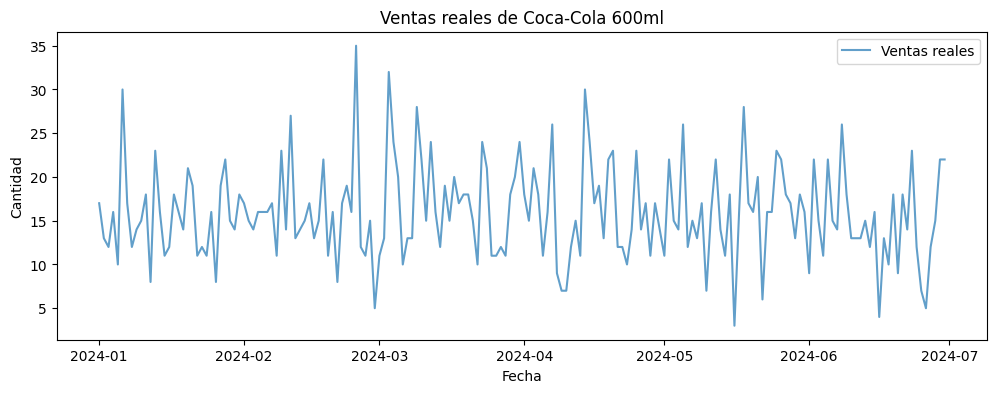

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(coca['fecha'], coca['cantidad'], label='Ventas reales', alpha=0.7)
plt.title("Ventas reales de Coca-Cola 600ml")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.legend()
plt.show()

In [17]:
# Predecir los proximos 7 dias
ultimo_dia = coca['dia_numero'].max()
fechas_futuras = pd.date_range(start='2024-07-01', periods=7, freq='D')

datos_futuros = pd.DataFrame({
    'dia_numero': range(ultimo_dia + 1, ultimo_dia + 8),
    'es_fin_semana': (fechas_futuras.weekday >= 5).astype(int)
})

predicciones_futuras = modelo.predict(datos_futuros) 

for fecha, pred in zip(fechas_futuras, predicciones_futuras):
    print(f"{fecha.date()} ({'fin de semana' if fecha.weekday() >= 5 else 'semana'}): {pred:.0f} unidades")

2024-07-01 (semana): 13 unidades
2024-07-02 (semana): 13 unidades
2024-07-03 (semana): 13 unidades
2024-07-04 (semana): 13 unidades
2024-07-05 (semana): 13 unidades
2024-07-06 (fin de semana): 18 unidades
2024-07-07 (fin de semana): 18 unidades


In [18]:
import joblib

# Guardar el modelo
joblib.dump(modelo, 'modelo_coca_cola.pkl')

# Verificar que se puede cargar y predecir
modelo_cargado = joblib.load('modelo_coca_cola.pkl')
print("Modelo cargado correctamente")
print(f"Prediccion de prueba: {modelo_cargado.predict([[182, 0]])[0]:.0f} unidades")

Modelo cargado correctamente
Prediccion de prueba: 13 unidades


/home/pulpo/miniconda3/envs/ds-journey/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [19]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib

load_dotenv(override=True)

engine = create_engine(
    f"postgresql://{os.getenv('INTELISTOCK_DB_USER')}:{os.getenv('INTELISTOCK_DB_PASSWORD')}@{os.getenv('INTELISTOCK_DB_HOST')}:{os.getenv('INTELISTOCK_DB_PORT')}/{os.getenv('INTELISTOCK_DB_NAME')}"
)

def cargar_datos_producto(producto_nombre, negocio_id=1):
    """Carga y prepara datos de ventas de un producto desde PostgreSQL."""
    df = pd.read_sql("""
        SELECT v.fecha, vd.cantidad
        FROM ventas v
        JOIN venta_detalle vd ON vd.venta_id = v.id
        JOIN productos p ON p.id = vd.producto_id
        WHERE p.nombre = %(nombre)s AND v.negocio_id = %(negocio_id)s
        ORDER BY v.fecha
    """, engine, params={"nombre": producto_nombre, "negocio_id": negocio_id})

    df['fecha'] = pd.to_datetime(df['fecha'])
    df['dia_numero'] = (df['fecha'] - df['fecha'].min()).dt.days
    df['dia_semana'] = df['fecha'].dt.weekday
    df['es_fin_semana'] = (df['dia_semana'] >= 5).astype(int)
    df['mes'] = df['fecha'].dt.month

    return df

# Probar
df_coca = cargar_datos_producto("Coca-Cola 600ml")
print(df_coca.shape)
df_coca.head()

(182, 6)


,fecha,cantidad,dia_numero,dia_semana,es_fin_semana,mes
0,2024-01-01,17,0,0,0,1
1,2024-01-02,13,1,1,0,1
2,2024-01-03,12,2,2,0,1
3,2024-01-04,16,3,3,0,1
4,2024-01-05,10,4,4,0,1


In [20]:
def entrenar_modelo(df):
    """Entrena un Random Forest con los datos del producto."""
    X = df[['dia_numero', 'dia_semana', 'es_fin_semana', 'mes']]
    y = df['cantidad']

    modelo = RandomForestRegressor(n_estimators=100, random_state=42)
    modelo.fit(X, y)

    # Evaluar con los mismos datos (referencia interna)
    mae = mean_absolute_error(y, modelo.predict(X))
    
    return modelo, mae

modelo_coca, mae_coca = entrenar_modelo(df_coca)
print(f"Modelo entrenado. MAE referencia: {mae_coca:.2f}")

Modelo entrenado. MAE referencia: 1.58


In [21]:
def predecir_proximos_dias(modelo, df, dias=7):
    """Predice la demanda de los próximos N días."""
    ultimo_dia = df['dia_numero'].max()
    ultima_fecha = df['fecha'].max()
    
    fechas_futuras = pd.date_range(
        start=ultima_fecha + pd.Timedelta(days=1),
        periods=dias,
        freq='D'
    )
    
    datos_futuros = pd.DataFrame({
        'dia_numero': range(ultimo_dia + 1, ultimo_dia + dias + 1),
        'dia_semana': fechas_futuras.weekday,
        'es_fin_semana': (fechas_futuras.weekday >= 5).astype(int),
        'mes': fechas_futuras.month
    })
    
    predicciones = modelo.predict(datos_futuros)
    
    resultado = pd.DataFrame({
        'fecha': fechas_futuras,
        'cantidad_predicha': predicciones.round().astype(int)
    })
    
    return resultado

# Predecir
prediccion = predecir_proximos_dias(modelo_coca, df_coca)
prediccion

,fecha,cantidad_predicha
0,2024-07-01,10
1,2024-07-02,9
2,2024-07-03,10
3,2024-07-04,11
4,2024-07-05,13
5,2024-07-06,20
6,2024-07-07,20


In [28]:
def pipeline_completo(producto_nombre, negocio_id=1, dias=7):
    """
    Pipeline completo: carga datos, entrena modelo, 
    predice y guarda el modelo entrenado.
    
    Returns:
        dict con predicciones y métricas
    """
    # 1. Cargar datos
    df = cargar_datos_producto(producto_nombre, negocio_id)
    
    if len(df) < 30:
        return {"error": "Datos insuficientes. Mínimo 30 días requeridos."}
    
    # 2. Entrenar
    modelo, mae = entrenar_modelo(df)
    
    # 3. Predecir
    prediccion = predecir_proximos_dias(modelo, df, dias)
    
    # 4. Guardar modelo
    nombre_archivo = f"modelo_{producto_nombre.replace(' ', '_').replace('/', '_')}.pkl"
    joblib.dump(modelo, nombre_archivo)
    
    return {
        "producto": producto_nombre,
        "mae": round(mae, 2),
        "dias_de_historial": len(df),
        "predicciones": prediccion.to_dict(orient='records')
    }

# Probar con todos los productos
productos = ["Coca-Cola 600ml", "Sabritas Original", "Pan Bimbo", "Leche Lala 1L"]

for producto in productos:
    resultado = pipeline_completo(producto)
    print(f"\n{resultado['producto']}")
    print(f"MAE: {resultado['mae']} | Historial: {resultado['dias_de_historial']} días")
    for pred in resultado['predicciones']:
        print(f"  {pred['fecha'].date()} → {pred['cantidad_predicha']} unidades")


Coca-Cola 600ml
MAE: 1.58 | Historial: 182 días
  2024-07-01 → 10 unidades
  2024-07-02 → 9 unidades
  2024-07-03 → 10 unidades
  2024-07-04 → 11 unidades
  2024-07-05 → 13 unidades
  2024-07-06 → 20 unidades
  2024-07-07 → 20 unidades

Sabritas Original
MAE: 1.16 | Historial: 182 días
  2024-07-01 → 12 unidades
  2024-07-02 → 13 unidades
  2024-07-03 → 12 unidades
  2024-07-04 → 11 unidades
  2024-07-05 → 11 unidades
  2024-07-06 → 11 unidades
  2024-07-07 → 12 unidades

Pan Bimbo
MAE: 0.63 | Historial: 180 días
  2024-07-01 → 3 unidades
  2024-07-02 → 4 unidades
  2024-07-03 → 4 unidades
  2024-07-04 → 4 unidades
  2024-07-05 → 4 unidades
  2024-07-06 → 5 unidades
  2024-07-07 → 7 unidades

Leche Lala 1L
MAE: 0.95 | Historial: 182 días
  2024-07-01 → 7 unidades
  2024-07-02 → 10 unidades
  2024-07-03 → 8 unidades
  2024-07-04 → 9 unidades
  2024-07-05 → 8 unidades
  2024-07-06 → 12 unidades
  2024-07-07 → 11 unidades
